In [245]:

from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output

from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, create_4q_gst_config
from mGST.visualization import plot_wall_time
from mGST.automatic_diff import automatic_gradient, hvp
import jax.numpy as jnp
import jax

backend = "iqmfakeapollo"
data_path = "../data/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Goal:

1. Verify the complexity of the cost function as a function of the system size. From the theory, this should be $\mathcal{O}(2^{3N})$
2. Verify the complexity of the gradient as a function of the cost function cost ($C$). From the theory this should be $\mathcal{O}(C)$. Furthermore, the Baur-Strassen theorem gaurantees this is bounded by a low factor: $C(\nabla f) \leq 5 C(f)$.
3. Verify the complexity of the Hessian-vector product as a function of the cost function cost ($C$). Again, this should be linear with the cost funciton cost: $\mathcal{O}(C)$.
4. Check the dependence of each of these for the different operators. There seems to be a dependance with the input dimension (at least for higher order derivatives). Check this when using a `lambda` funciton and when not.

# Tensor generation

In [19]:
# fixed kraus rank to really the dependence in the system size dimension
kraus_rank = 1
# In general, the max kraus rank would be dim**2 with dim = 2**n_qubits

In [10]:
# First using the JAX compilation with smaller qubits to see if this helps
dim_1q = 2

Q1_GST = GSTConfiguration(
    qubit_layouts=[[0]],
    gate_set="1QXYI",
    num_circuits=100,
    shots=1000,
    rank=kraus_rank,
)

kraus_tensor_mgst_1q, kraus_mgst_1q, povm_mgst_1q, state_mgst_1q, prob_matrix_1q, indices_list_1q = get_full_mgst_parameters_from_configuration(
    Q1_GST, backend, only_jax_variables=True
)

kraus_tensor_1q_target, povm_psd_1q_target, state_psd_1q_target = get_compressed_rep_from_mgst_output(kraus_mgst_1q, povm_mgst_1q, state_mgst_1q, kraus_rank=kraus_rank, state_rank=dim_1q, povm_rank=dim_1q)


2025-10-02 15:37:36,481 - iqm.benchmarks.logging_config - INFO - Now generating 100 random GST circuits...
2025-10-02 15:37:36,502 - iqm.benchmarks.logging_config - INFO - Will transpile all 100 circuits according to fixed physical layout
2025-10-02 15:37:36,502 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-10-02 15:37:36,621 - iqm.benchmarks.logging_config - INFO - Submitting batch with 100 circuits corresponding to qubits [0]
2025-10-02 15:37:36,622 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-10-02 15:37:36,877 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [12]:
dim_2q = 2**2

Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=kraus_rank,
)

kraus_tensor_mgst_2q, kraus_mgst_2q, povm_mgst_2q, state_mgst_2q, prob_matrix_2q, indices_list_2q = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, only_jax_variables=True
)

kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target = get_compressed_rep_from_mgst_output(kraus_mgst_2q, povm_mgst_2q, state_mgst_2q, kraus_rank=kraus_rank, state_rank=dim_2q, povm_rank=dim_2q)

2025-10-02 15:43:03,243 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2025-10-02 15:43:03,724 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2025-10-02 15:43:03,725 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-10-02 15:43:05,026 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2025-10-02 15:43:05,027 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-10-02 15:43:05,097 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [30]:
dim_3q = 2**3

Q3_GST = GSTConfiguration(
    qubit_layouts=[[0,1,3]],
    gate_set="3QXYCZ",
    num_circuits=1000,
    shots=1000,
    rank=kraus_rank,
)

kraus_tensor_mgst_3q, kraus_mgst_3q, povm_mgst_3q, state_mgst_3q, prob_matrix_3q, indices_list_3q = get_full_mgst_parameters_from_configuration(
    Q3_GST, backend, only_jax_variables=True
)

kraus_tensor_3q_target, povm_psd_3q_target, state_psd_3q_target = get_compressed_rep_from_mgst_output(kraus_mgst_3q, povm_mgst_3q, state_mgst_3q, kraus_rank=kraus_rank, state_rank=dim_3q, povm_rank=dim_3q)

2025-10-02 16:03:32,716 - iqm.benchmarks.logging_config - INFO - Now generating 1000 random GST circuits...
2025-10-02 16:03:32,927 - iqm.benchmarks.logging_config - INFO - Will transpile all 1000 circuits according to fixed physical layout
2025-10-02 16:03:32,927 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-10-02 16:03:35,125 - iqm.benchmarks.logging_config - INFO - Submitting batch with 1000 circuits corresponding to qubits [0, 1, 3]
2025-10-02 16:03:35,127 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-10-02 16:03:35,182 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [20]:
dim_4q = 2**4
Q4_GST = create_4q_gst_config(kraus_rank=kraus_rank)

kraus_tensor_mgst_4q, kraus_mgst_4q, povm_mgst_4q, state_mgst_4q, prob_matrix_4q, indices_list_4q = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend, only_jax_variables=True
)

kraus_tensor_4q_target, povm_psd_4q_target, state_psd_4q_target = get_compressed_rep_from_mgst_output(kraus_mgst_4q, povm_mgst_4q, state_mgst_4q, kraus_rank=kraus_rank, state_rank=dim_4q, povm_rank=dim_4q)

2025-10-02 15:47:39,154 - iqm.benchmarks.logging_config - INFO - Now generating 2000 random GST circuits...
2025-10-02 15:47:39,814 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2025-10-02 15:47:39,815 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-10-02 15:47:43,156 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1, 3, 4]
2025-10-02 15:47:43,159 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-10-02 15:47:43,214 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [88]:
input_1q = {
    "kraus_tensor": kraus_tensor_1q_target,
    "povm_psd": povm_psd_1q_target,
    "state_psd": state_psd_1q_target,
    "prob_matrix": prob_matrix_1q,
    "indices_list": indices_list_1q,
}

input_2q = {
    "kraus_tensor": kraus_tensor_2q_target,
    "povm_psd": povm_psd_2q_target,
    "state_psd": state_psd_2q_target,
    "prob_matrix": prob_matrix_2q,
    "indices_list": indices_list_2q,
}

input_3q = {
    "kraus_tensor": kraus_tensor_3q_target,
    "povm_psd": povm_psd_3q_target,
    "state_psd": state_psd_3q_target,
    "prob_matrix": prob_matrix_3q,
    "indices_list": indices_list_3q,
}

input_4q = {
    "kraus_tensor": kraus_tensor_4q_target,
    "povm_psd": povm_psd_4q_target,
    "state_psd": state_psd_4q_target,
    "prob_matrix": prob_matrix_4q,
    "indices_list": indices_list_4q,   
}

print(len(indices_list_1q[-1]), len(indices_list_2q[-1]), len(indices_list_3q[-1]), len(indices_list_4q[-1]))
print(len(indices_list_1q), len(indices_list_2q), len(indices_list_3q), len(indices_list_4q))
print(prob_matrix_1q.shape, prob_matrix_2q.shape, prob_matrix_3q.shape, prob_matrix_4q.shape)

prob_matrices = [prob_matrix_1q, prob_matrix_2q, prob_matrix_3q, prob_matrix_4q]
num_sequences_list = [matrix.shape[1] for matrix in prob_matrices]
num_povms = [matrix.shape[0] for matrix in prob_matrices]

14 14 14 14
100 800 1000 2000
(2, 100) (4, 800) (8, 1000) (16, 2000)


In [92]:
num_povms, num_sequences_list

([2, 4, 8, 16], [100, 800, 1000, 2000])

# Cost function

First, we run once each of them to let it compile

In [ ]:
cost_1q = cost_function_jax_mps(jit=True, **input_1q)
cost_2q = cost_function_jax_mps(jit=True, **input_2q)
cost_3q = cost_function_jax_mps(jit=True, **input_3q)
cost_4q = cost_function_jax_mps(jit=True, **input_4q)

In [34]:
# Store timing result in a variable
timing_1q = %timeit -o cost_function_jax_mps(jit=True, **input_1q)
timing_2q = %timeit -o cost_function_jax_mps(jit=True, **input_2q)
timing_3q = %timeit -o cost_function_jax_mps(jit=True, **input_3q)
timing_4q = %timeit -o cost_function_jax_mps(jit=True, **input_4q)

2.38 ms ± 56 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
28.1 ms ± 1.21 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
38.6 ms ± 1.85 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
203 ms ± 1.04 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [355]:
timing_cost_1q_no_jit = %timeit -o cost_function_jax_mps(jit=False, **input_1q)
timing_cost_2q_no_jit = %timeit -o cost_function_jax_mps(jit=False, **input_2q)
timing_cost_3q_no_jit = %timeit -o cost_function_jax_mps(jit=False, **input_3q)
timing_cost_4q_no_jit = %timeit -o cost_function_jax_mps(jit=False, **input_4q)

122 ms ± 2.04 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
988 ms ± 20 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.29 s ± 5.97 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.82 s ± 20 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [356]:

timings_cost_fn = [timing_1q, timing_2q, timing_3q, timing_4q]
tuples_cost_fn = [(time.average, time.stdev) for time in timings_cost_fn]
tuples_cost_fn_scaled = [(time.average/(num_seq), time.stdev/(num_seq)) for time, num_seq in zip(timings_cost_fn, num_sequences_list)]
# tuples_cost_fn_scaled = [(time.average/(num_seq * num_povm), time.stdev/(num_seq * num_povm)) for time, num_seq, num_povm in zip(timings_cost_fn, num_sequences_list, num_povms)]

timings_cost_fn_no_jit = [timing_cost_1q_no_jit, timing_cost_2q_no_jit, timing_cost_3q_no_jit, timing_cost_4q_no_jit]
tuples_cost_fn_no_jit = [(time.average, time.stdev) for time in timings_cost_fn_no_jit]
tuples_cost_fn_no_jit_scaled = [(time.average/(num_seq), time.stdev/(num_seq)) for time, num_seq in zip(timings_cost_fn_no_jit, num_sequences_list)]

2025-10-07 12:02:28,432 - matplotlib.mathtext - INFO - Substituting symbol O from STIXNonUnicode
2025-10-07 12:02:28,513 - matplotlib.mathtext - INFO - Substituting symbol O from STIXNonUnicode


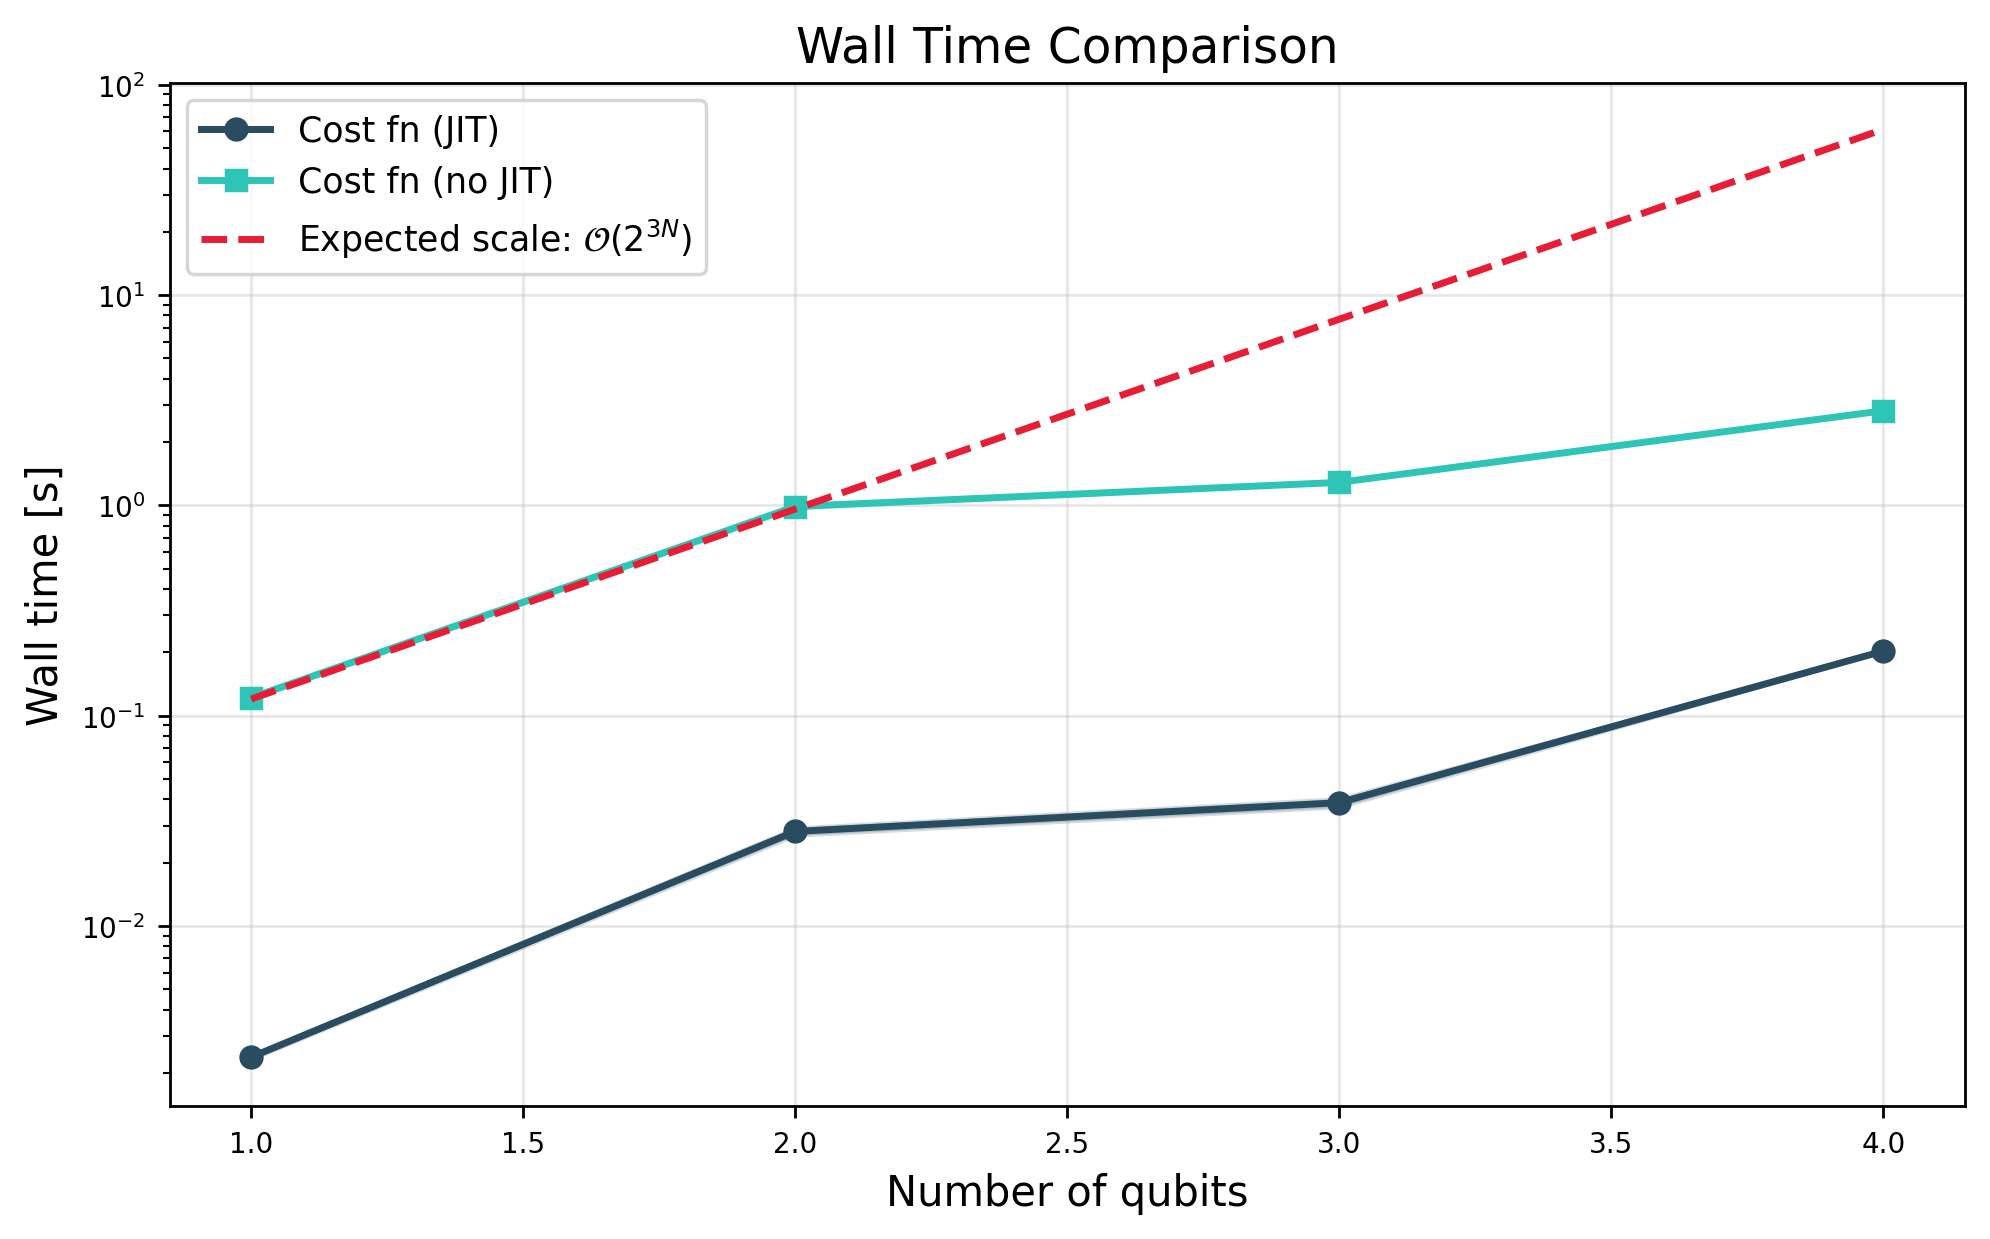

In [360]:
cost_fn_times = {
    "Cost fn (JIT)": tuples_cost_fn,
    "Cost fn (no JIT)": tuples_cost_fn_no_jit,
    # "Cost fn (no JIT) - (scaled by num sequences)": tuples_cost_fn_no_jit_scaled,
    # "Cost fn (scaled by num sequences)": tuples_cost_fn_scaled,
}

x_data = jnp.arange(1, 5)
y_data = 2**(3 * x_data) * 1.5e-2
# y_data = 2**(3 * x_data) * 1e-5
comparison_data = {
    r"Expected scale: $\mathcal{O}(2^{3N}$)": (x_data, y_data)
}

num_qubits = [1, 2, 3, 4]

plot_wall_time(cost_fn_times, num_qubits, logscale="y", comparison_data=comparison_data)

# Gradient

In [215]:
kwargs_kraus_1q = input_1q.copy()
kwargs_kraus_1q.pop("kraus_tensor")
fn_kraus_1q = lambda x: cost_function_jax_mps(kraus_tensor = x, jit=True, **kwargs_kraus_1q)
grad_fn_kraus_1q = automatic_gradient(fn_kraus_1q)

kwargs_kraus_2q = input_2q.copy()
kwargs_kraus_2q.pop("kraus_tensor")
fn_kraus_2q = lambda x: cost_function_jax_mps(kraus_tensor = x, jit=True, **kwargs_kraus_2q)
grad_fn_kraus_2q = automatic_gradient(fn_kraus_2q)

kwargs_kraus_3q = input_3q.copy()
kwargs_kraus_3q.pop("kraus_tensor")
fn_kraus_3q = lambda x: cost_function_jax_mps(kraus_tensor = x, jit=True, **kwargs_kraus_3q)
grad_fn_kraus_3q = automatic_gradient(fn_kraus_3q)

kwargs_kraus_4q = input_4q.copy()
kwargs_kraus_4q.pop("kraus_tensor")
fn_kraus_4q = lambda x: cost_function_jax_mps(kraus_tensor = x, jit=True, **kwargs_kraus_4q)
grad_fn_kraus_4q = automatic_gradient(fn_kraus_4q)

In [216]:
timing_grad_kraus_1q = %timeit -o grad_fn_kraus_1q(kraus_tensor_1q_target)
timing_grad_kraus_2q = %timeit -o grad_fn_kraus_2q(kraus_tensor_2q_target)
timing_grad_kraus_3q = %timeit -o grad_fn_kraus_3q(kraus_tensor_3q_target)
timing_grad_kraus_4q = %timeit -o grad_fn_kraus_4q(kraus_tensor_4q_target)

133 ms ± 1.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.04 s ± 21 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.25 s ± 2.93 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.55 s ± 5.78 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [217]:
kwargs_state_1q = input_1q.copy()
kwargs_state_1q.pop("state_psd")
fn_state_1q = lambda x: cost_function_jax_mps(state_psd=x, jit=True, **kwargs_state_1q)
grad_fn_state_1q = automatic_gradient(fn_state_1q)

kwargs_state_2q = input_2q.copy()
kwargs_state_2q.pop("state_psd")
fn_state_2q = lambda x: cost_function_jax_mps(state_psd = x, jit=True, **kwargs_state_2q)
grad_fn_state_2q = automatic_gradient(fn_state_2q)

kwargs_state_3q = input_3q.copy()
kwargs_state_3q.pop("state_psd")
fn_state_3q = lambda x: cost_function_jax_mps(state_psd = x, jit=True, **kwargs_state_3q)
grad_fn_state_3q = automatic_gradient(fn_state_3q)

kwargs_state_4q = input_4q.copy()
kwargs_state_4q.pop("state_psd")
fn_state_4q = lambda x: cost_function_jax_mps(state_psd = x, jit=True, **kwargs_state_4q)
grad_fn_state_4q = automatic_gradient(fn_state_4q)

In [218]:
# Store timing result in a variable
timing_grad_state_1q = %timeit -o grad_fn_state_1q(state_psd_1q_target)
timing_grad_state_2q = %timeit -o grad_fn_state_2q(state_psd_2q_target)
timing_grad_state_3q = %timeit -o grad_fn_state_3q(state_psd_3q_target)
timing_grad_state_4q = %timeit -o grad_fn_state_4q(state_psd_4q_target)

70.3 ms ± 2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
538 ms ± 3.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
664 ms ± 2.17 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.35 s ± 4.06 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [219]:
kwargs_povm_1q = input_1q.copy()
kwargs_povm_1q.pop("povm_psd")
fn_povm_1q = lambda x: cost_function_jax_mps(povm_psd=x, jit=True, **kwargs_povm_1q)
grad_fn_povm_1q = automatic_gradient(fn_povm_1q)

kwargs_povm_2q = input_2q.copy()
kwargs_povm_2q.pop("povm_psd")
fn_povm_2q = lambda x: cost_function_jax_mps(povm_psd=x, jit=True, **kwargs_povm_2q)
grad_fn_povm_2q = automatic_gradient(fn_povm_2q)

kwargs_povm_3q = input_3q.copy()
kwargs_povm_3q.pop("povm_psd")
fn_povm_3q = lambda x: cost_function_jax_mps(povm_psd=x, jit=True, **kwargs_povm_3q)
grad_fn_povm_3q = automatic_gradient(fn_povm_3q)


kwargs_povm_4q = input_4q.copy()
kwargs_povm_4q.pop("povm_psd")
fn_povm_4q = lambda x: cost_function_jax_mps(povm_psd=x, jit=True, **kwargs_povm_4q)
grad_fn_povm_4q = automatic_gradient(fn_povm_4q)

In [220]:
timing_grad_povm_1q = %timeit -o grad_fn_povm_1q(povm_psd_1q_target)
timing_grad_povm_2q = %timeit -o grad_fn_povm_2q(povm_psd_2q_target)
timing_grad_povm_3q = %timeit -o grad_fn_povm_3q(povm_psd_3q_target)
timing_grad_povm_4q = %timeit -o grad_fn_povm_4q(povm_psd_4q_target)

44.2 ms ± 1.03 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
356 ms ± 35.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
430 ms ± 1.49 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
900 ms ± 6.79 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


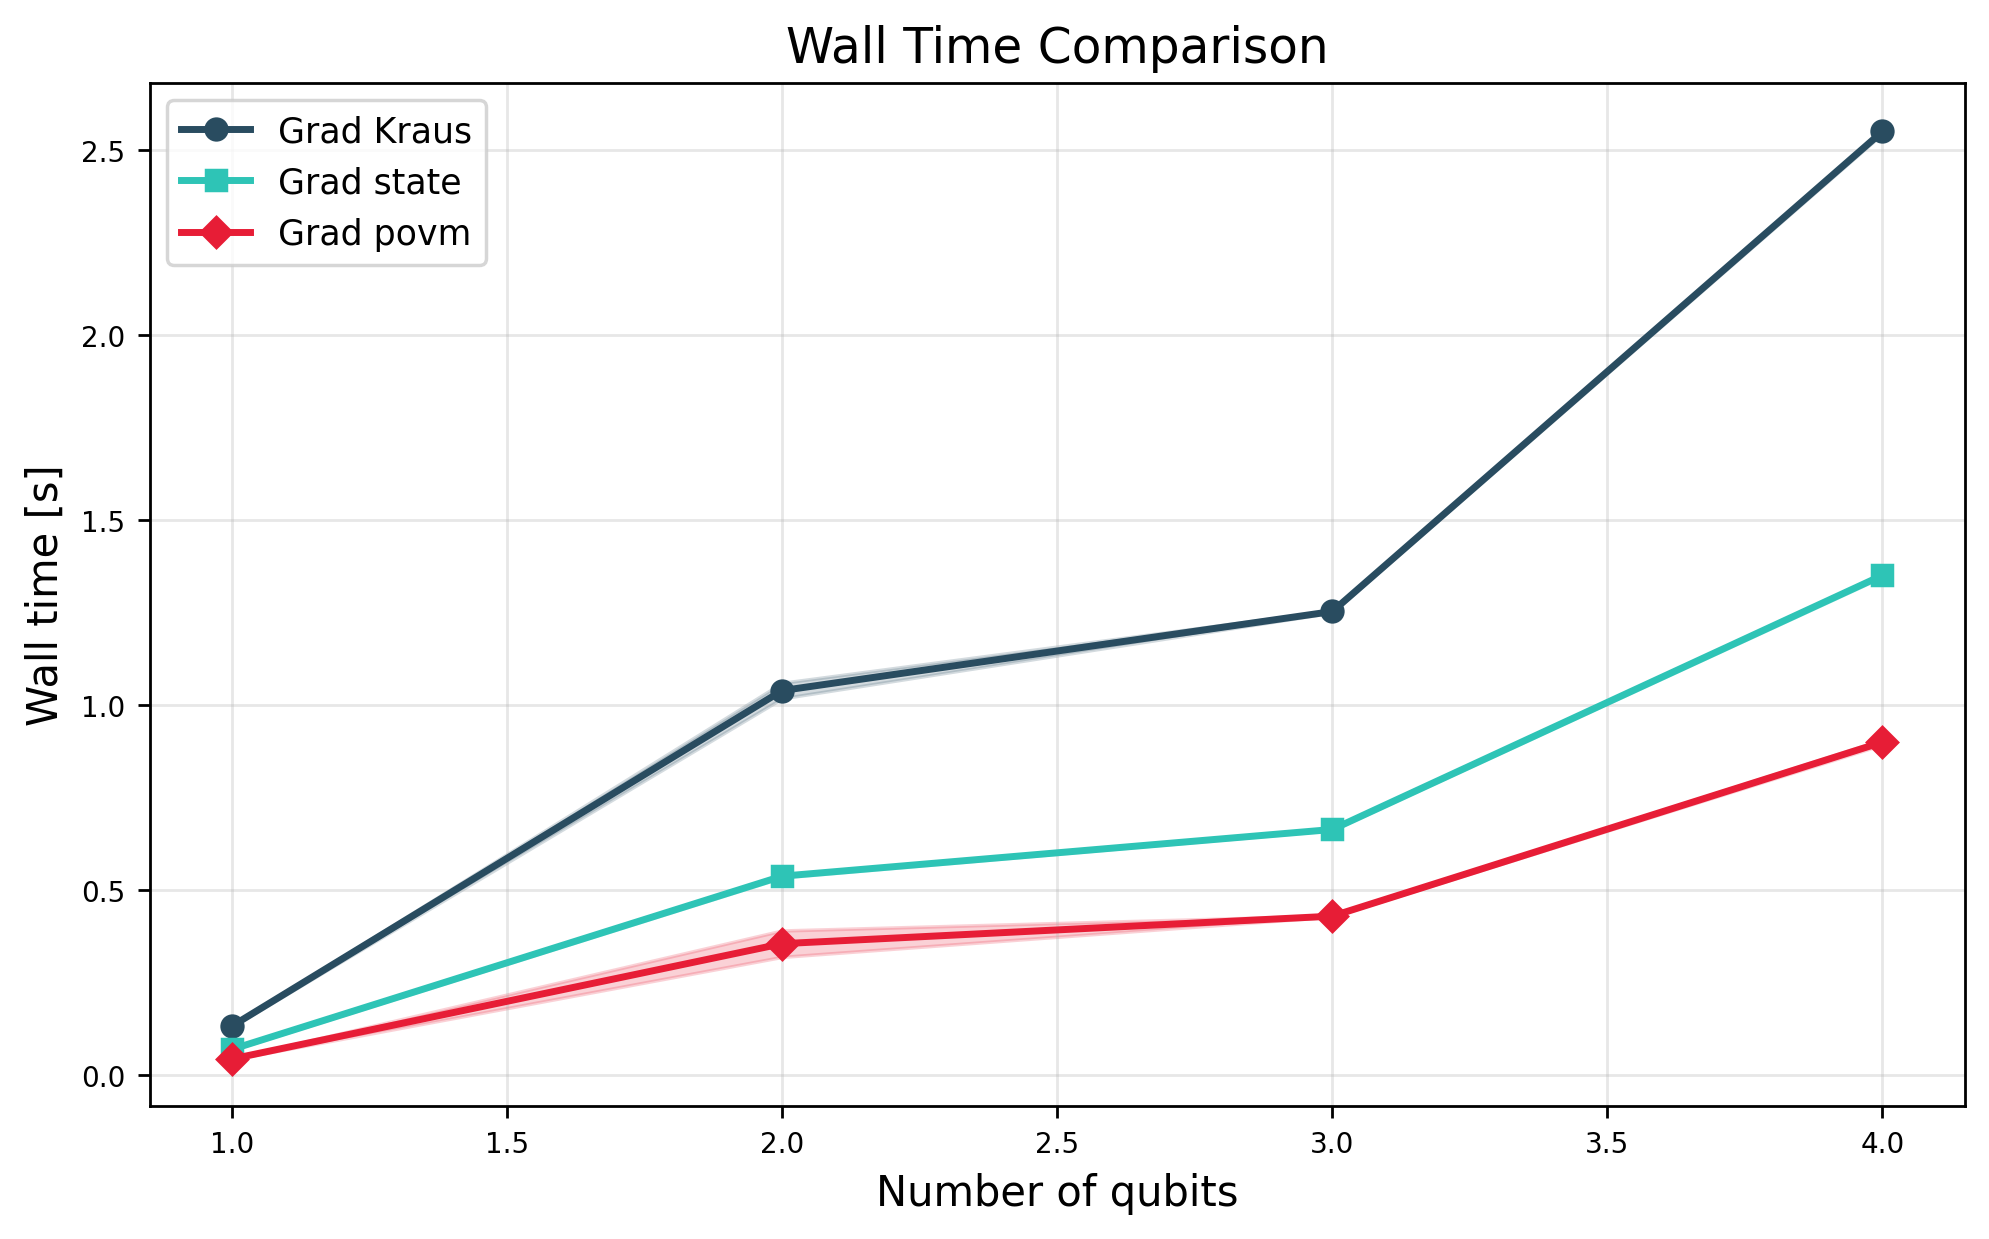

In [365]:
timings_grad_kraus = [timing_grad_kraus_1q, timing_grad_kraus_2q, timing_grad_kraus_3q, timing_grad_kraus_4q]
tuples_grad_kraus = [(time.average, time.stdev) for time in timings_grad_kraus]
tuples_grad_kraus_scaled = [(time_grad.average/(time_fn.average), time_grad.stdev/(time_fn.average)) for time_grad, time_fn in zip(timings_grad_kraus, timings_cost_fn)]

timings_grad_state = [timing_grad_state_1q, timing_grad_state_2q, timing_grad_state_3q, timing_grad_state_4q]
tuples_grad_state = [(time.average, time.stdev) for time in timings_grad_state]
tuples_grad_state_scaled = [(time_grad.average/(time_fn.average), time_grad.stdev/(time_fn.average)) for time_grad, time_fn in zip(timings_grad_state, timings_cost_fn)]

timings_grad_povm = [timing_grad_povm_1q, timing_grad_povm_2q, timing_grad_povm_3q, timing_grad_povm_4q]
tuples_grad_povm = [(time.average, time.stdev) for time in timings_grad_povm]
tuples_grad_povm_scaled = [(time_grad.average/(time_fn.average), time_grad.stdev/(time_fn.average)) for time_grad, time_fn in zip(timings_grad_povm, timings_cost_fn)]

# Use this as x axis to compare againts the cost function
cost_fn_time_list = [avg_std[0] for avg_std in tuples_cost_fn]
xlabel = "Cost Function Time (s)"

grad_all_times = {
    "Grad Kraus": tuples_grad_kraus,
    "Grad state": tuples_grad_state,
    "Grad povm": tuples_grad_povm,
    # "Grad kraus (scaled)": tuples_grad_kraus_scaled,
    # "Grad state (scaled)": tuples_grad_state_scaled,
    # "Grad povm (scaled)": tuples_grad_povm_scaled,
}
plot_wall_time(grad_all_times, num_qubits, logscale=None)
# plot_wall_time(grad_all_times, cost_fn_time_list, logscale=None, xlabel=xlabel)

In [148]:
# Does it depend on whether we are creating an additional function or not?

# JVP

In [223]:
# create the tangent vectors for each case.
vector_kraus_1q = grad_fn_kraus_1q(kraus_tensor_1q_target)
vector_kraus_2q = grad_fn_kraus_2q(kraus_tensor_2q_target)
vector_kraus_3q = grad_fn_kraus_3q(kraus_tensor_3q_target)
vector_kraus_4q = grad_fn_kraus_4q(kraus_tensor_4q_target)

vector_state_1q = grad_fn_state_1q(state_psd_1q_target)
vector_state_2q = grad_fn_state_2q(state_psd_2q_target)
vector_state_3q = grad_fn_state_3q(state_psd_3q_target)
vector_state_4q = grad_fn_state_4q(state_psd_4q_target)

vector_povm_1q = grad_fn_povm_1q(povm_psd_1q_target)
vector_povm_2q = grad_fn_povm_2q(povm_psd_2q_target)
vector_povm_3q = grad_fn_povm_3q(povm_psd_3q_target)
vector_povm_4q = grad_fn_povm_4q(povm_psd_4q_target)

In [224]:
timing_hvp_kraus_1q = %timeit -o hvp(grad_fn_kraus_1q, kraus_tensor_1q_target, vector_kraus_1q)
timing_hvp_kraus_2q = %timeit -o hvp(grad_fn_kraus_2q, kraus_tensor_2q_target, vector_kraus_2q)
timing_hvp_kraus_3q = %timeit -o hvp(grad_fn_kraus_3q, kraus_tensor_3q_target, vector_kraus_3q)
timing_hvp_kraus_4q = %timeit -o hvp(grad_fn_kraus_4q, kraus_tensor_4q_target, vector_kraus_4q)

172 ms ± 1.81 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.41 s ± 103 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.68 s ± 3.87 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
3.47 s ± 11.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [225]:
timing_hvp_povm_1q = %timeit -o hvp(grad_fn_povm_1q, povm_psd_1q_target, vector_povm_1q)
timing_hvp_povm_2q = %timeit -o hvp(grad_fn_povm_2q, povm_psd_2q_target, vector_povm_2q)
timing_hvp_povm_3q = %timeit -o hvp(grad_fn_povm_3q, povm_psd_3q_target, vector_povm_3q)
timing_hvp_povm_4q = %timeit -o hvp(grad_fn_povm_4q, povm_psd_4q_target, vector_povm_4q)

58.2 ms ± 1.11 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
458 ms ± 4.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
584 ms ± 30.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.21 s ± 18 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [226]:
timing_hvp_state_1q = %timeit -o hvp(grad_fn_state_1q, state_psd_1q_target, vector_state_1q)
timing_hvp_state_2q = %timeit -o hvp(grad_fn_state_2q, state_psd_2q_target, vector_state_2q)
timing_hvp_state_3q = %timeit -o hvp(grad_fn_state_3q, state_psd_3q_target, vector_state_3q)
timing_hvp_state_4q = %timeit -o hvp(grad_fn_state_4q, state_psd_4q_target, vector_state_4q)

91.3 ms ± 1.18 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
714 ms ± 3.21 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
891 ms ± 12.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.81 s ± 5.28 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


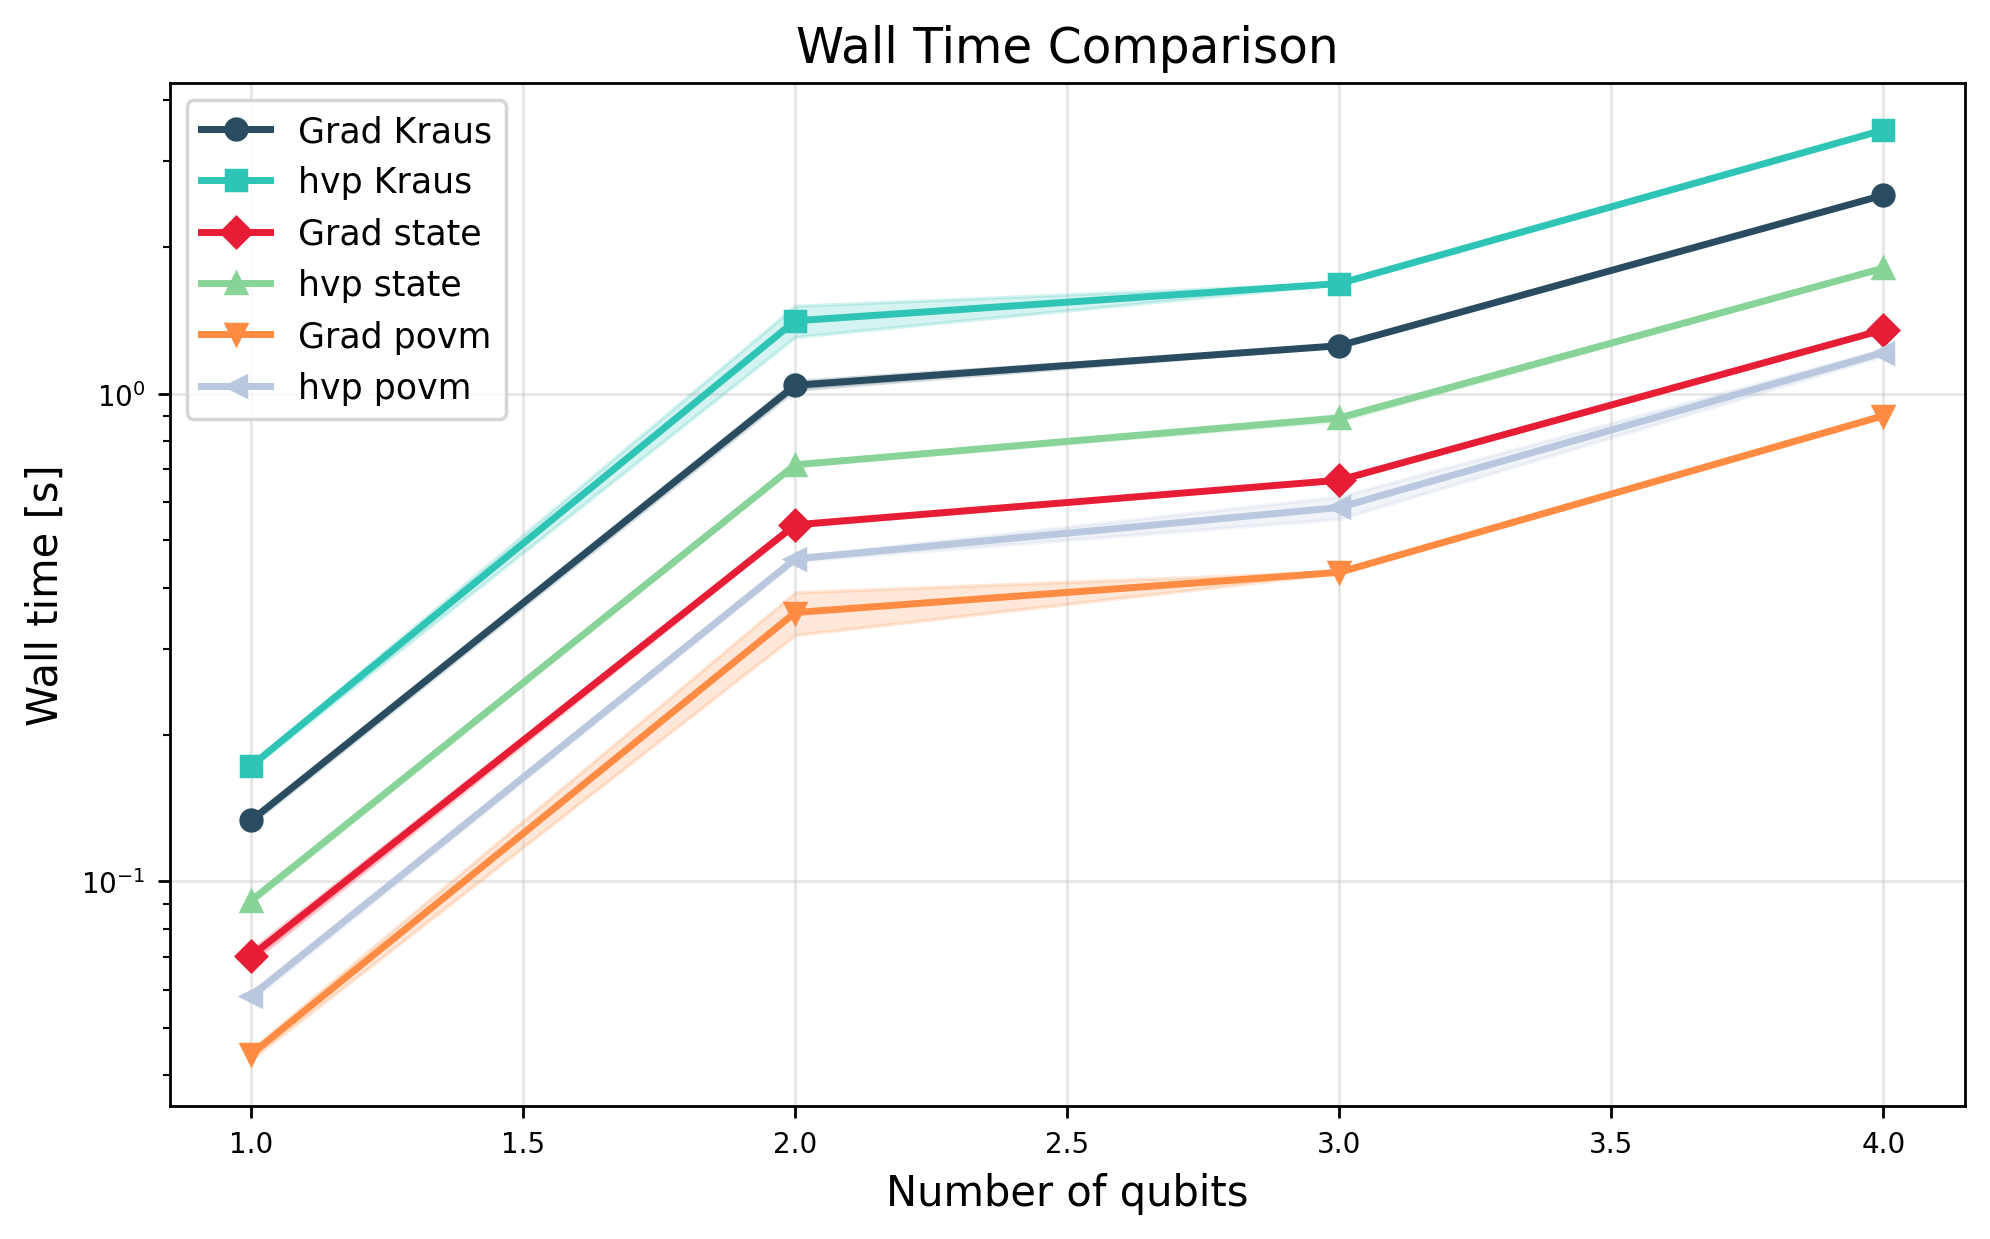

In [366]:
timings_hvp_kraus = [timing_hvp_kraus_1q, timing_hvp_kraus_2q, timing_hvp_kraus_3q, timing_hvp_kraus_4q]
tuples_hvp_kraus = [(time.average, time.stdev) for time in timings_hvp_kraus]
tuples_hvp_kraus_scaled = [(time_hvp.average/(time_fn.average), time_hvp.stdev/(time_fn.average)) for time_hvp, time_fn in zip(timings_hvp_kraus, timings_cost_fn)]

timings_hvp_state = [timing_hvp_state_1q, timing_hvp_state_2q, timing_hvp_state_3q, timing_hvp_state_4q]
tuples_hvp_state = [(time.average, time.stdev) for time in timings_hvp_state]
tuples_hvp_state_scaled = [(time_hvp.average/(time_fn.average), time_hvp.stdev/(time_fn.average)) for time_hvp, time_fn in zip(timings_hvp_state, timings_cost_fn)]

timings_hvp_povm = [timing_hvp_povm_1q, timing_hvp_povm_2q, timing_hvp_povm_3q, timing_hvp_povm_4q]
tuples_hvp_povm = [(time.average, time.stdev) for time in timings_hvp_povm]
tuples_hvp_povm_scaled = [(time_hvp.average/(time_fn.average), time_hvp.stdev/(time_fn.average)) for time_hvp, time_fn in zip(timings_hvp_povm, timings_cost_fn)]

hvp_all_times = {
    "Grad Kraus": tuples_grad_kraus,
    "hvp Kraus": tuples_hvp_kraus,
    "Grad state": tuples_grad_state,
    "hvp state": tuples_hvp_state,
    "Grad povm": tuples_grad_povm,
    "hvp povm": tuples_hvp_povm,
    # "hvp kraus (scaled)": tuples_hvp_kraus_scaled,
    # "hvp state (scaled)": tuples_hvp_state_scaled,
    # "hvp povm (scaled)": tuples_hvp_povm_scaled,
}
plot_wall_time(hvp_all_times, num_qubits, logscale="y")
# plot_wall_time(hvp_all_times, cost_fn_time_list, logscale=None, xlabel=xlabel)

In [308]:
from mGST.low_level_jit import cost_function_mps_single_gate_sequence, cost_function_mps_single_gate_sequence_jit
jax.make_jaxpr(cost_function_mps_single_gate_sequence)(kraus_tensor_1q_target, povm_psd_1q_target, state_psd_1q_target, indices_list_1q[0], prob_matrix_1q[:,0])

{ lambda ; a:c128[3,1,2,2] b:c128[2,2,2] c:c128[2,2] d:i64[0] e:f64[2]. let
    f:c128[2,2] = conj[input_dtype=complex128] c
    g:c128[2,2] = transpose[permutation=(1, 0)] f
    h:c128[2,2] = dot_general[
      dimension_numbers=(([1], [0]), ([], []))
      preferred_element_type=complex128
    ] c g
    _:i64[0] = rev[dimensions=(0,)] d
    i:c128[2,2,2] = conj[input_dtype=complex128] b
    j:c128[2,2,2] = dot_general[
      dimension_numbers=(([0], [2]), ([], []))
      preferred_element_type=complex128
    ] h b
    k:c128[2] = dot_general[
      dimension_numbers=(([1, 2], [2, 0]), ([0], [1]))
      preferred_element_type=complex128
    ] i j
    l:c128[2] = convert_element_type[new_dtype=complex128 weak_type=False] e
    m:c128[2] = sub k l
    n:f64[2] = abs m
    o:f64[2] = integer_pow[y=2] n
    p:f64[] = reduce_sum[axes=(0,)] o
  in (p,) }

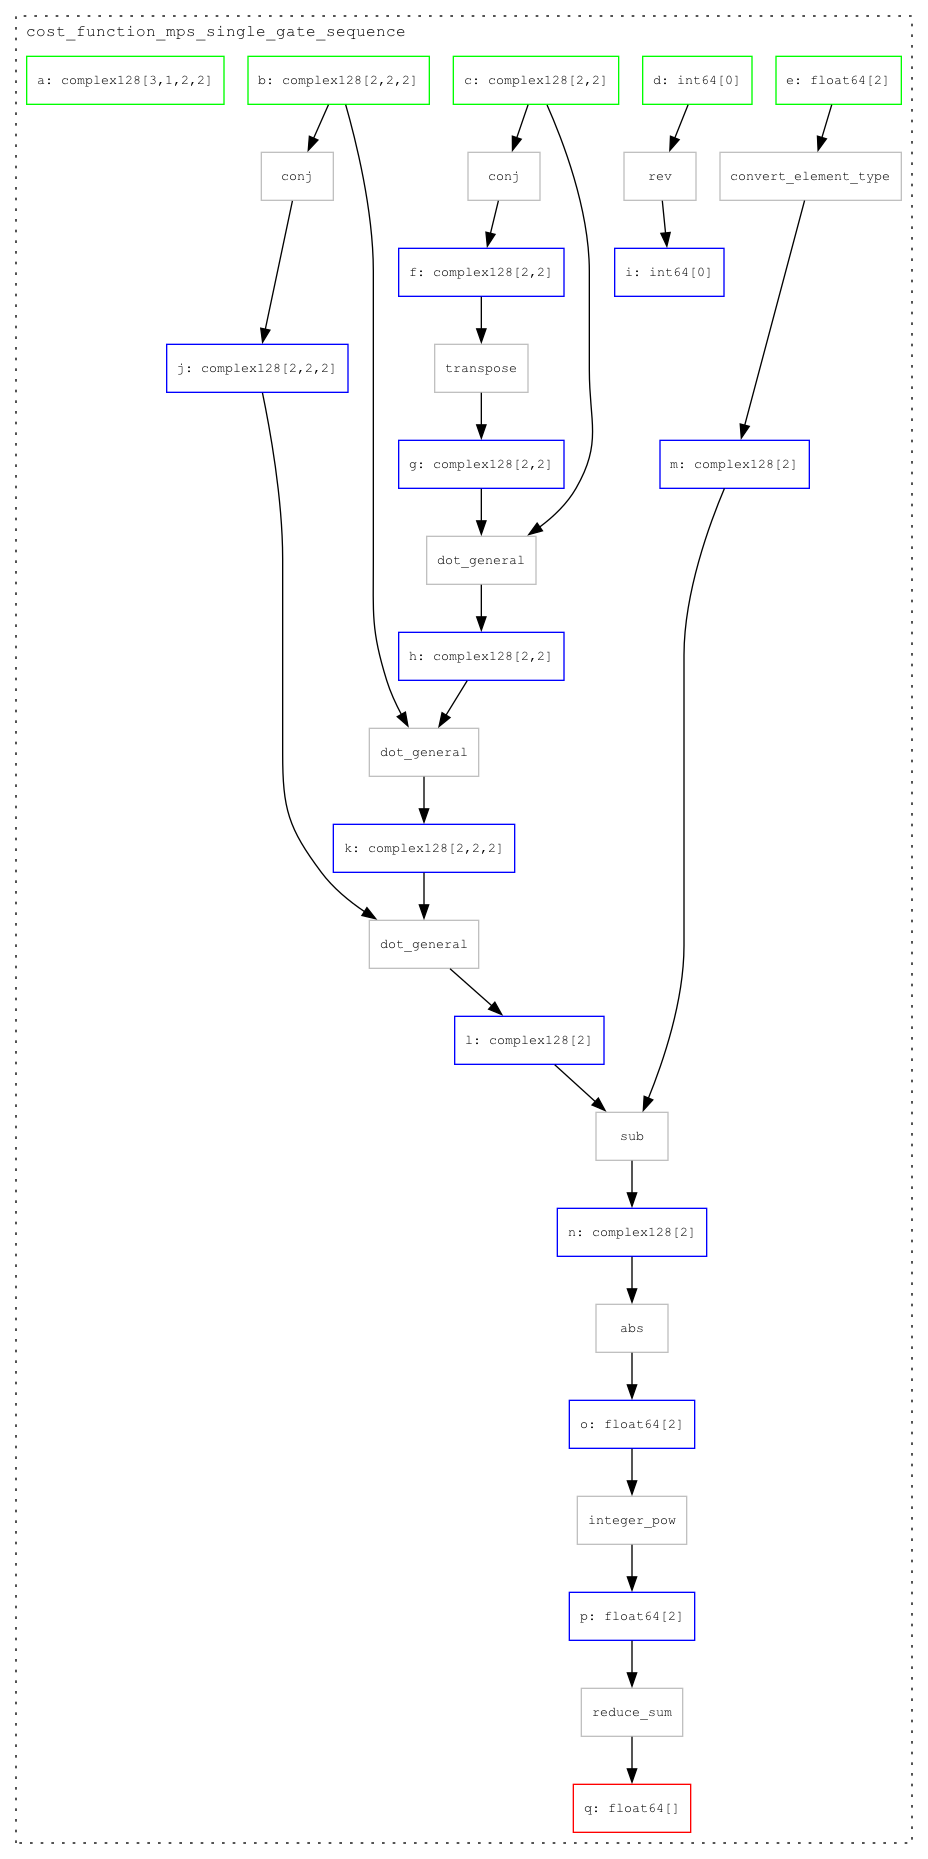

In [313]:
import jpviz

dot_graph = jpviz.draw(cost_function_mps_single_gate_sequence_jit, collapse_primitives=False)(kraus_tensor_1q_target, povm_psd_1q_target, state_psd_1q_target, indices_list_1q[0], prob_matrix_1q[:,0])
jpviz.view_pydot(dot_graph)

# Minimum example for JAX question

In [238]:
import jax
import jax.numpy as jnp

def cost_fn(x1:jnp.ndarray, x2:jnp.ndarray, x3:jnp.ndarray)-> float:
    # some tensor contractions
    matrix = x1
    d = 10
    for _ in range(d):
        matrix = matrix @ x1
    return (x2 @ matrix @ x3).real

key = jax.random.PRNGKey(42)
key1, key2, key3, key4, key5, key6 = jax.random.split(key, 6)

# tensor dimensions
n1 = int(2*1e2)
n2 = int(1e2)
n3 = int(1e2)

# Complex matrix and vectors
x1 = jax.random.normal(key1, shape=(n1//2, n1//2)) + 1j * jax.random.normal(key2, shape=(n1//2, n1//2))
x2 = jax.random.normal(key3, shape=(n2,)) + 1j * jax.random.normal(key4, shape=(n2,))
x3 = jax.random.normal(key5, shape=(n3,)) + 1j * jax.random.normal(key6, shape=(n3,))

# Create tangent vectors for JVP calculations
v1 = jax.random.normal(key1, shape=(n1//2, n1//2)) + 1j * jax.random.normal(key2, shape=(n1//2, n1//2))
v2 = jax.random.normal(key3, shape=(n2,)) + 1j * jax.random.normal(key4, shape=(n2,))
v3 = jax.random.normal(key5, shape=(n3,)) + 1j * jax.random.normal(key6, shape=(n3,))

# Define individual functions
f_1 = lambda x: cost_fn(x, x2, x3)
grad_x1 = jax.grad(f_1)

f_2 = lambda x: cost_fn(x1, x, x3)
grad_x2 = jax.grad(f_2)

f_3 = lambda x: cost_fn(x1, x2, x)
grad_x3 = jax.grad(f_3)

In [239]:
%timeit grad_x1(x1)

5.11 ms ± 565 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [240]:
%timeit grad_x2(x2)

3.01 ms ± 449 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [241]:
%timeit grad_x3(x3)

3.25 ms ± 243 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [242]:
%timeit jax.jvp(grad_x1, (x1,) , (v1,))

10.5 ms ± 188 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [243]:
%timeit jax.jvp(grad_x2, (x2,) , (v2,))

2.72 ms ± 171 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [244]:
%timeit jax.jvp(grad_x3, (x3,) , (v3,))

4.05 ms ± 228 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
